<a href="https://colab.research.google.com/github/AlexanderOlivera/Analisis-de-algoritmos/blob/main/Fibonacci%3Acomparaci%C3%B3n_iterativo_vs_recursivo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fibonacci: comparación **iterativo** vs **recursivo** (visual y experimental)
Materia: Diseño y Análisis de Algoritmos (5º semestre)

Este notebook sirve para **ver y medir** el comportamiento de Fibonacci en dos versiones:
- **Iterativa** (tiempo lineal)
- **Recursiva ingenua** (tiempo exponencial)

Incluye:
- Instrumentación (conteo de operaciones/llamadas)
- Medición de tiempos
- Gráficas para comparar crecimiento

> Nota: La versión recursiva ingenua crece muy rápido. Por eso acotamos `n` para evitar esperas largas.


In [ ]:
import math
import time
from time import perf_counter
import matplotlib.pyplot as plt
import pandas as pd

%matplotlib inline


## 1) Implementaciones
A continuación definimos Fibonacci iterativo y Fibonacci recursivo (ingenuo). También añadimos **instrumentación**:
- En recursivo: contamos **cuántas llamadas** se hacen.
- En iterativo: contamos **cuántas iteraciones** se ejecutan.


In [ ]:
def fib_iter(n: int):
    """Fibonacci iterativo con conteo de iteraciones.
    Retorna (F(n), iteraciones).
    """
    if n < 0:
        raise ValueError("n debe ser >= 0")
    if n <= 1:
        return n, 0
    a, b = 0, 1
    iters = 0
    for _ in range(2, n + 1):
        a, b = b, a + b
        iters += 1
    return b, iters

def fib_rec_naive(n: int):
    """Fibonacci recursivo ingenuo con conteo de llamadas.
    Retorna (F(n), llamadas_totales).
    """
    if n < 0:
        raise ValueError("n debe ser >= 0")
    calls = 0

    def _fib(k: int):
        nonlocal calls
        calls += 1
        if k <= 1:
            return k
        return _fib(k - 1) + _fib(k - 2)

    value = _fib(n)
    return value, calls


Probemos con un valor pequeño para verificar que ambas versiones entregan el mismo resultado.

In [ ]:
for n in range(0, 11):
    vi, _ = fib_iter(n)
    vr, _ = fib_rec_naive(n)
    print(n, vi, vr, "OK" if vi == vr else "DIFF")


0 0 0 OK
1 1 1 OK
2 1 1 OK
3 2 2 OK
4 3 3 OK
5 5 5 OK
6 8 8 OK
7 13 13 OK
8 21 21 OK
9 34 34 OK
10 55 55 OK


## 2) Visualización del crecimiento de trabajo
### 2.1 Conteo de iteraciones vs llamadas
En iterativo, el trabajo crece aproximadamente como `n`.

En recursivo ingenuo, el número de llamadas crece aproximadamente proporcional a `F(n)` (y por tanto **exponencial**).


In [ ]:
def run_counts(n_values):
    rows = []
    for n in n_values:
        fi, iters = fib_iter(n)
        fr, calls = fib_rec_naive(n)
        rows.append({
            "n": n,
            "F(n)": fi,
            "iteraciones_iterativo": iters,
            "llamadas_recursivo": calls,
        })
    return pd.DataFrame(rows)

# Ojo: el recursivo ingenuo explota rápido; mantenemos un rango moderado.
n_counts = list(range(0, 31))
df_counts = run_counts(n_counts)
df_counts.head(10)


,n,F(n),iteraciones_iterativo,llamadas_recursivo
0,0,0,0,1
1,1,1,0,1
2,2,1,1,3
3,3,2,2,5
4,4,3,3,9
5,5,5,4,15
6,6,8,5,25
7,7,13,6,41
8,8,21,7,67
9,9,34,8,109


### Gráfica: conteo de trabajo (escala lineal)
Se verá que el recursivo sube muchísimo más rápido.


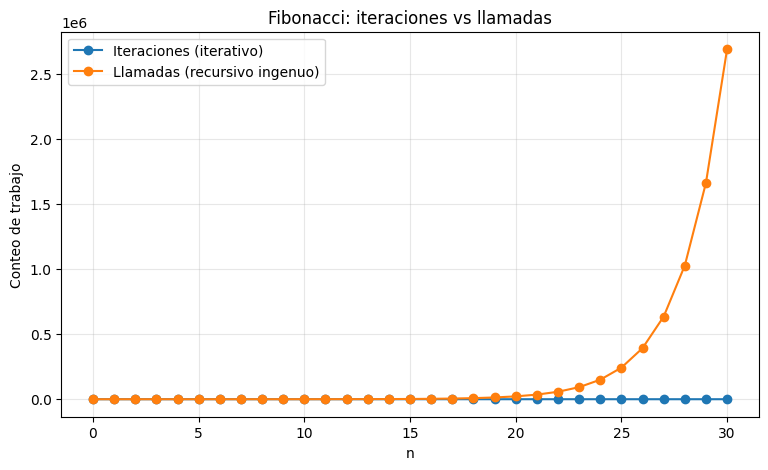

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(df_counts["n"], df_counts["iteraciones_iterativo"], marker="o", label="Iteraciones (iterativo)")
plt.plot(df_counts["n"], df_counts["llamadas_recursivo"], marker="o", label="Llamadas (recursivo ingenuo)")
plt.xlabel("n")
plt.ylabel("Conteo de trabajo")
plt.title("Fibonacci: iteraciones vs llamadas")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


### Gráfica: conteo de trabajo (escala logarítmica)
La escala logarítmica ayuda a comparar cuando una curva crece exponencialmente.


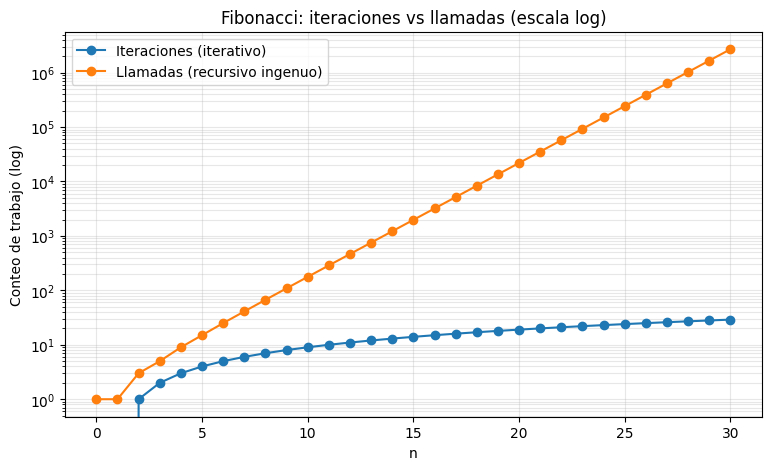

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(df_counts["n"], df_counts["iteraciones_iterativo"], marker="o", label="Iteraciones (iterativo)")
plt.plot(df_counts["n"], df_counts["llamadas_recursivo"], marker="o", label="Llamadas (recursivo ingenuo)")
plt.yscale("log")
plt.xlabel("n")
plt.ylabel("Conteo de trabajo (log)")
plt.title("Fibonacci: iteraciones vs llamadas (escala log)")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()


## 3) Medición de tiempos (benchmark)
Medimos el tiempo de ejecución promedio (en milisegundos) para distintos valores de `n`.

Recomendación didáctica:
- Iterativo: podemos subir `n` sin problema.
- Recursivo ingenuo: usamos `n` más pequeño.


In [ ]:
def time_function(fn, n: int, repeats: int = 5):
    # medimos el mejor de varios intentos cortos
    best = float("inf")
    for _ in range(repeats):
        t0 = perf_counter()
        fn(n)
        t1 = perf_counter()
        best = min(best, t1 - t0)
    return best

def fib_iter_value(n: int):
    return fib_iter(n)[0]

def fib_rec_value(n: int):
    return fib_rec_naive(n)[0]


### 3.1 Tiempos comparables (rango donde ambos aún son ejecutables)
Aquí usamos un rango donde el recursivo todavía termina rápido.


In [ ]:
# Ajusta si tu equipo es más lento/rápido
n_time = list(range(0, 36))  # el recursivo puede tardar mucho hacia el final

rows = []
for n in n_time:
    t_iter = time_function(fib_iter_value, n, repeats=7)
    # Para recursivo, reducimos repeticiones porque puede tardar
    t_rec = time_function(fib_rec_value, n, repeats=3)
    rows.append({
        "n": n,
        "tiempo_iter_ms": t_iter * 1000,
        "tiempo_rec_ms": t_rec * 1000,
    })

df_time = pd.DataFrame(rows)
df_time.tail(10)


,n,tiempo_iter_ms,tiempo_rec_ms
26,26,0.002015,102.823702
27,27,0.002590,118.241805
28,28,0.003021,231.912252
29,29,0.001575,166.015893
30,30,0.001569,268.418477
31,31,0.001653,438.332052
32,32,0.001662,933.046124
33,33,0.001771,1165.997466
34,34,0.001706,1904.430259
35,35,0.001870,3079.021666


### Gráfica de tiempos (ms)
Normalmente se observa que el recursivo despega (crece) mucho antes.


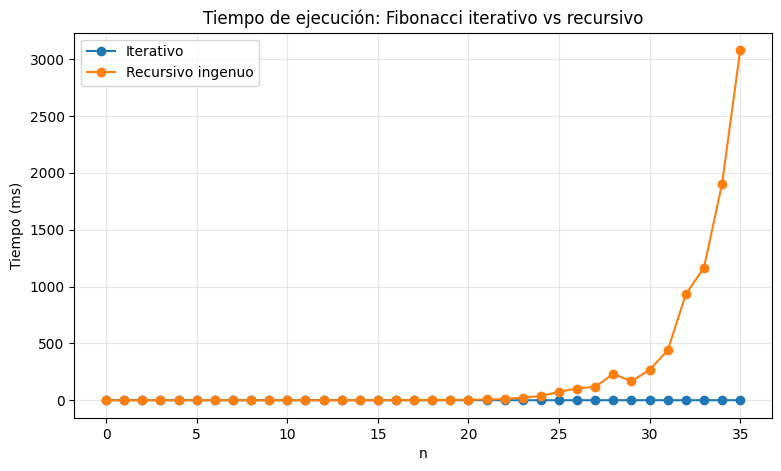

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(df_time["n"], df_time["tiempo_iter_ms"], marker="o", label="Iterativo")
plt.plot(df_time["n"], df_time["tiempo_rec_ms"], marker="o", label="Recursivo ingenuo")
plt.xlabel("n")
plt.ylabel("Tiempo (ms)")
plt.title("Tiempo de ejecución: Fibonacci iterativo vs recursivo")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


### Gráfica de tiempos (escala log)
En escala log, una tendencia aproximadamente lineal sugiere crecimiento exponencial en escala normal.


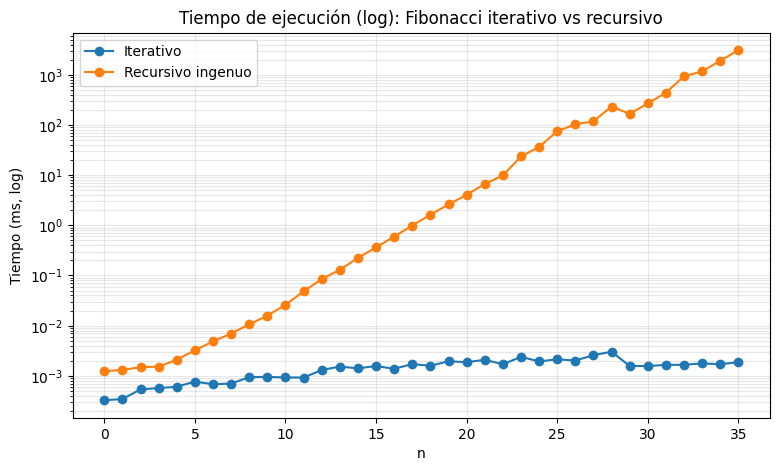

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(df_time["n"], df_time["tiempo_iter_ms"], marker="o", label="Iterativo")
plt.plot(df_time["n"], df_time["tiempo_rec_ms"], marker="o", label="Recursivo ingenuo")
plt.yscale("log")
plt.xlabel("n")
plt.ylabel("Tiempo (ms, log)")
plt.title("Tiempo de ejecución (log): Fibonacci iterativo vs recursivo")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()


## 4) Preguntas para discusión en clase
1. ¿Por qué el recursivo ingenuo repite trabajo? (subproblemas repetidos)
2. Si el iterativo es O(n), ¿por qué el recursivo ingenuo es ~O(φ^n)?
3. ¿Qué papel juega la **pila de llamadas** en el costo espacial del recursivo?
4. ¿Qué técnica permite mantener la idea recursiva pero evitar repetición? (Pista: memoización / programación dinámica)
5. ¿Cómo cambiaría el análisis si Fibonacci fuera recursión de cola y el lenguaje optimizara Tail Call?


## 5) Extensión opcional (para la siguiente clase)
Implementa Fibonacci recursivo **con memoización** y compáralo en las mismas gráficas.
Eso conecta directamente con **Programación Dinámica**.
